In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster

In [2]:
df = pd.read_csv('CC GENERAL.csv')

In [3]:
df.shape

(8950, 18)

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
numerical_features = df.select_dtypes(include=[np.number]).columns
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].mean())
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [7]:
x = df[numerical_features]

In [8]:
scaler = StandardScaler()
sc_x = scaler.fit_transform(x)

In [ ]:
z = linkage(sc_x,method='ward')  # it creates a linkage matrix

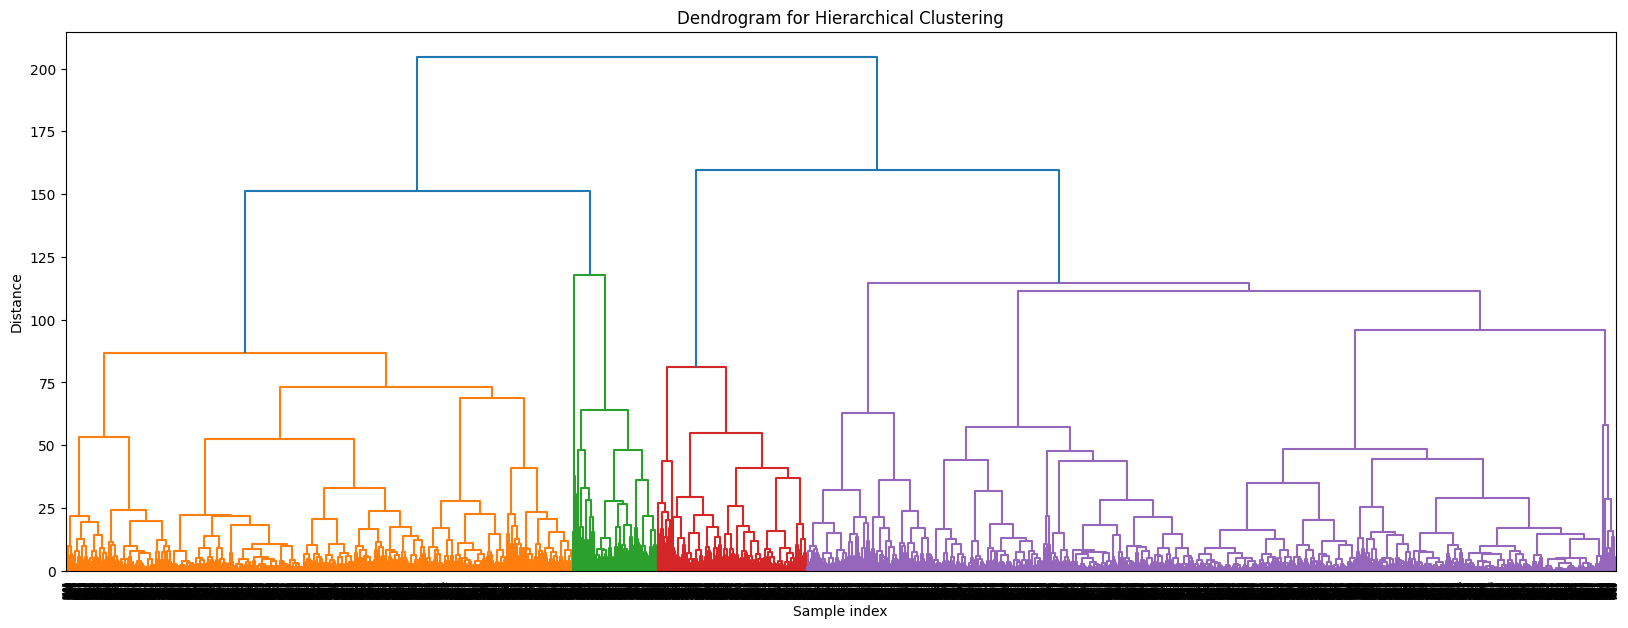

In [12]:
plt.figure(figsize=(20, 7))
dendrogram(z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

In [22]:
# from dendogram the top right vertical line will be selected bcoz its the longest vertical line from which no horizontal line passes.
# by drawing threashold, it passes from 2 lines. so no. of clusteers = 2

In [ ]:
# If You want to automatically determine the best number of clusters then use silhouette_score.
# Otherwise decide the number of clusters based on the dendrogram, by looking at the point where the longest vertical line doesn't get intersected by any more horizontal lines.
from sklearn.metrics import silhouette_score
sil_scores = []
optimal_k = 2
max_sil_score = -1

for k in range(2,20):
    cluster = AgglomerativeClustering(n_clusters=k)
    cluster_labels = cluster.fit_predict(sc_x)
    score = silhouette_score(sc_x, cluster_labels)
    sil_scores.append(score)
    if score > max_sil_score:
        max_sil_score = score
        optimal_k = k

In [73]:
print(max_sil_score)

0.1775448235536517


In [74]:
print(optimal_k)

2


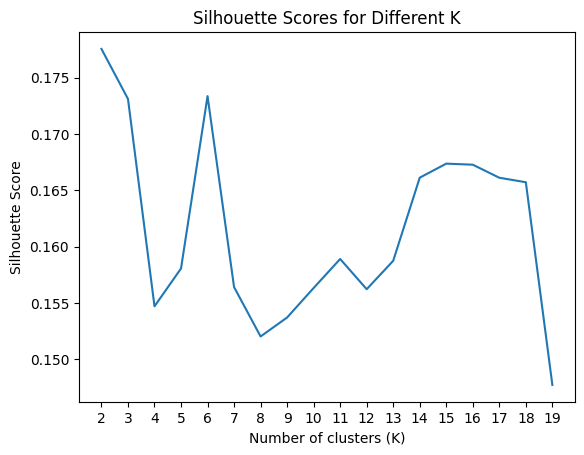

In [21]:
plt.plot(range(2, 20), sil_scores)
plt.xticks(range(2, 20))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K")
plt.show()

In [56]:
new = fcluster(z, optimal_k, criterion='maxclust') 
# It Cuts the dendrogram at a point that results in exactly optimal_k clusters. And It assigns a cluster label to each data point, where each data point is assigned to one of the optimal_k clusters.

In [46]:
df['Cluster'] = new

In [47]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


In [51]:
df['Cluster'].value_counts()

Cluster
2    5532
1    3418
Name: count, dtype: int64

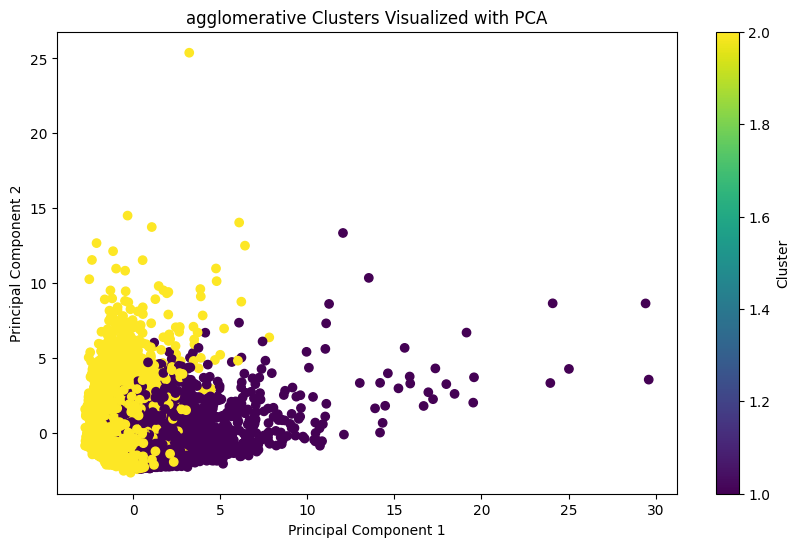

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(sc_x)

plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:,0],pca_components[:,1],c=df['Cluster'],cmap='viridis')
plt.title('agglomerative Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [52]:
print(df.groupby('Cluster').mean(numeric_only=True))

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
1        1421.515706           0.977681  2095.399383       1223.915281   
2        1652.803511           0.815231   328.381809        202.272603   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
1                    871.803171     423.06606             0.879285   
2                    126.397719    1322.28067             0.250044   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
1                          0.397512                          0.683356   
2                          0.081941                          0.167390   

         CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
Cluster                                                      

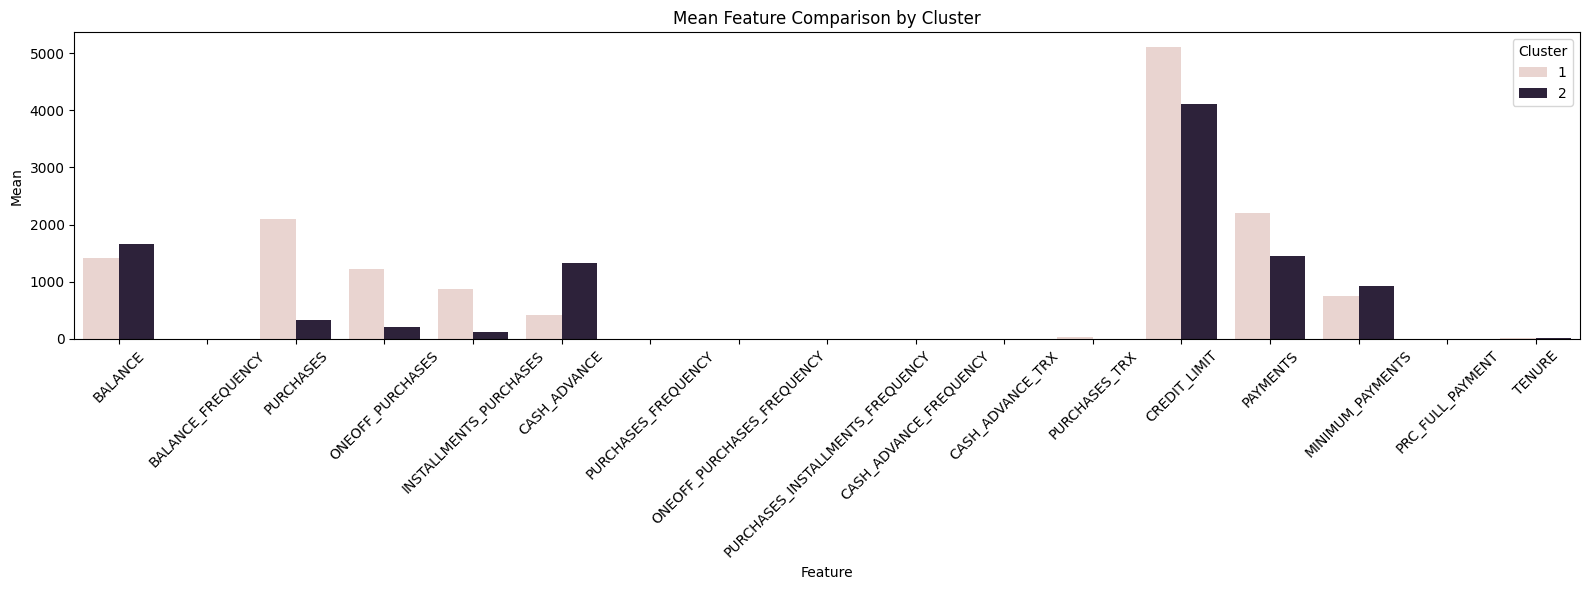

In [59]:
import seaborn as sns

# Melt the data for seaborn
cluster_means = df.groupby('Cluster').mean(numeric_only=True)
mean_df = cluster_means.reset_index().melt(id_vars='Cluster', var_name='Feature', value_name='Mean')
# melt function is used to reshape the data. It converts the DataFrame from a wide format to a long format.

plt.figure(figsize=(16, 6))
sns.barplot(data=mean_df, x='Feature', y='Mean', hue='Cluster')
plt.title('Mean Feature Comparison by Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [58]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
x = df[numerical_features]
y = df['Cluster']

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [63]:
regressor = RandomForestClassifier()

In [64]:
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [65]:
rcv = GridSearchCV(regressor, param_grid=parameters, cv=5, scoring='r2')

In [66]:
rcv.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [67]:
rcv.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

In [68]:
print(rcv.best_score_)

0.8329658150096974


In [69]:
y_pred = rcv.predict(x_test)

In [70]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [71]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.8195550859735423
MAE: 0.04289544235924933
MSE: 0.04289544235924933


In [72]:
from sklearn.metrics import confusion_matrix,classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.92      0.94       871
           2       0.95      0.98      0.97      1367

    accuracy                           0.96      2238
   macro avg       0.96      0.95      0.95      2238
weighted avg       0.96      0.96      0.96      2238

Confusion Matrix:
[[ 805   66]
 [  30 1337]]
